In [11]:
# install and import the libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# load the data
data=pd.read_csv(r'C:\Users\dell\Downloads\archive (6)\Car_Insurance_Claim.csv')

In [13]:
# Understanding of data
data.head(5)# first 5 rows


,ID,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,569520,65+,female,majority,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,16-25,male,majority,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,16-25,female,majority,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,16-25,male,majority,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,26-39,male,majority,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


In [14]:
print(data.shape) # how many rows and columns

(10000, 19)


In [15]:
data.info() # data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   10000 non-null  int64  
 1   AGE                  10000 non-null  object 
 2   GENDER               10000 non-null  object 
 3   RACE                 10000 non-null  object 
 4   DRIVING_EXPERIENCE   10000 non-null  object 
 5   EDUCATION            10000 non-null  object 
 6   INCOME               10000 non-null  object 
 7   CREDIT_SCORE         9018 non-null   float64
 8   VEHICLE_OWNERSHIP    10000 non-null  float64
 9   VEHICLE_YEAR         10000 non-null  object 
 10  MARRIED              10000 non-null  float64
 11  CHILDREN             10000 non-null  float64
 12  POSTAL_CODE          10000 non-null  int64  
 13  ANNUAL_MILEAGE       9043 non-null   float64
 14  VEHICLE_TYPE         10000 non-null  object 
 15  SPEEDING_VIOLATIONS  10000 non-null  

In [16]:
 data.isnull().sum().sum() # checking for null values

1939

In [17]:
data.isnull().sum() # checking for the null columns

ID                       0
AGE                      0
GENDER                   0
RACE                     0
DRIVING_EXPERIENCE       0
EDUCATION                0
INCOME                   0
CREDIT_SCORE           982
VEHICLE_OWNERSHIP        0
VEHICLE_YEAR             0
MARRIED                  0
CHILDREN                 0
POSTAL_CODE              0
ANNUAL_MILEAGE         957
VEHICLE_TYPE             0
SPEEDING_VIOLATIONS      0
DUIS                     0
PAST_ACCIDENTS           0
OUTCOME                  0
dtype: int64

In [18]:
# Data cleaning (filling the missing values)

In [19]:
data["CREDIT_SCORE"]= data["CREDIT_SCORE"].fillna(data["CREDIT_SCORE"].median())
data["ANNUAL_MILEAGE"]=data["ANNUAL_MILEAGE"].fillna(data["ANNUAL_MILEAGE"].median())
                                                  

In [20]:
data.isnull().sum().sum()

0

In [21]:
# checking for duplicates

In [22]:
data.duplicated().any()

False

<Figure size 1000x500 with 0 Axes>

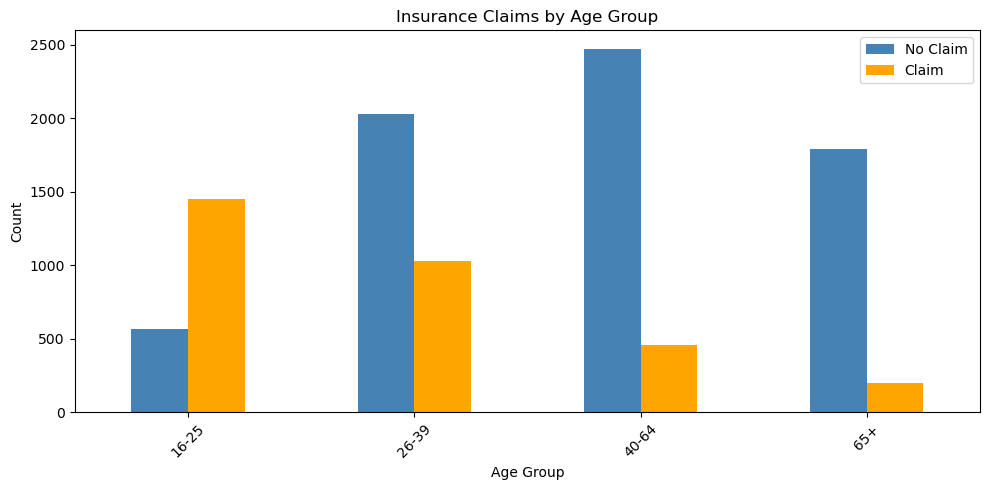

In [31]:
# Explore the data (EDA)
# claims by age_group
# Chart 1: Claims by age group

plt.figure(figsize=(10, 5))
age_outcome = data.groupby(['AGE', 'OUTCOME']).size().unstack(fill_value=0)
age_outcome.plot(kind='bar', figsize=(10, 5), color=['steelblue', 'orange'])
plt.title('Insurance Claims by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(['No Claim', 'Claim'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('claims_by_age.png')
plt.show()


           
              
              

<Figure size 800x500 with 0 Axes>

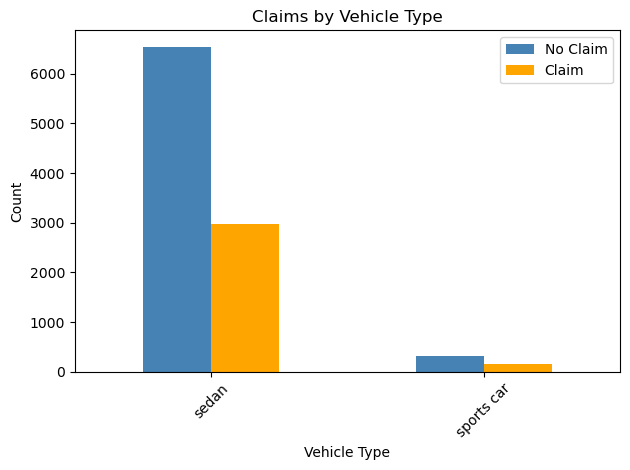

In [36]:
 
# Chart 2: Claims by vehicle type
plt.figure(figsize=(8, 5))
vehicle_outcome = data.groupby(['VEHICLE_TYPE', 'OUTCOME']).size().unstack(fill_value=0)
vehicle_outcome.plot(kind='bar', color=['steelblue', 'orange'])
plt.title('Claims by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Count')
plt.legend(['No Claim', 'Claim'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('claims_by_vehicle.png')
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_6628\1077305122.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  credit_outcome = data.groupby(['CREDIT_SCORE_RANGE', 'OUTCOME']).size().unstack(fill_value=0)


<Figure size 1000x500 with 0 Axes>

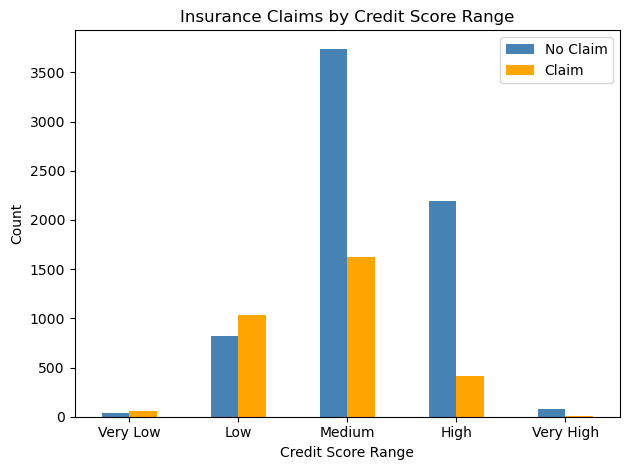

In [42]:
# Chart 2: Claims by credit score
# Chart: Claims by Credit Score Range
plt.figure(figsize=(10, 5))

# Group credit score into ranges
data['CREDIT_SCORE_RANGE'] = pd.cut(data['CREDIT_SCORE'], 
                                     bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
                                     labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

credit_outcome = data.groupby(['CREDIT_SCORE_RANGE', 'OUTCOME']).size().unstack(fill_value=0)
credit_outcome.plot(kind='bar', color=['steelblue', 'orange'])
plt.title('Insurance Claims by Credit Score Range')
plt.xlabel('Credit Score Range')
plt.ylabel('Count')
plt.legend(['No Claim', 'Claim'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('claims_by_credit_score.png')
plt.show()

In [44]:
data=data.drop(['ID','POSTAL_CODE'],axis=1)

In [62]:
# Step 1: Drop the problem column from the full dataset
data = data.drop(columns=['CREDIT_SCORE_RANGE'], errors='ignore')

# Step 2: Check what columns are still text
print("Text columns remaining:")
print(data.select_dtypes(include=['object', 'category']).columns.tolist())

Text columns remaining:
[]


In [63]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode all text columns automatically
for col in data.select_dtypes(include=['object', 'category']).columns:
    if col != 'OUTCOME':  # skip target column
        data[col] = le.fit_transform(data[col].astype(str))
        print(f"Encoded: {col}")

print("\nDone! All columns now:")
print(data.dtypes)


Done! All columns now:
AGE                          int64
DRIVING_EXPERIENCE           int64
EDUCATION                    int64
INCOME                       int64
CREDIT_SCORE               float64
VEHICLE_OWNERSHIP          float64
VEHICLE_YEAR                 int64
MARRIED                    float64
CHILDREN                   float64
ANNUAL_MILEAGE             float64
SPEEDING_VIOLATIONS          int64
DUIS                         int64
PAST_ACCIDENTS               int64
OUTCOME                    float64
GENDER_male                   bool
RACE_minority                 bool
VEHICLE_TYPE_sports car       bool
dtype: object


In [64]:
# Rebuild X and y cleanly
X = data.drop('OUTCOME', axis=1)
y = data['OUTCOME']

# Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("Any text columns left:", X_train.select_dtypes(include=['object','category']).columns.tolist())

X_train shape: (8000, 16)
Any text columns left: []


In [65]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_predictions = lr.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)
print(f"Logistic Regression Accuracy: {lr_accuracy:.2%}")

Logistic Regression Accuracy: 83.95%


In [66]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
rf_predictions = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"Random Forest Accuracy: {rf_accuracy:.2%}")

Random Forest Accuracy: 83.65%


Top 10 Features:
                Feature  Importance
1    DRIVING_EXPERIENCE    0.221417
5     VEHICLE_OWNERSHIP    0.137319
0                   AGE    0.107221
4          CREDIT_SCORE    0.102753
6          VEHICLE_YEAR    0.081718
12       PAST_ACCIDENTS    0.075377
10  SPEEDING_VIOLATIONS    0.068793
9        ANNUAL_MILEAGE    0.055339
13          GENDER_male    0.035242
3                INCOME    0.028445


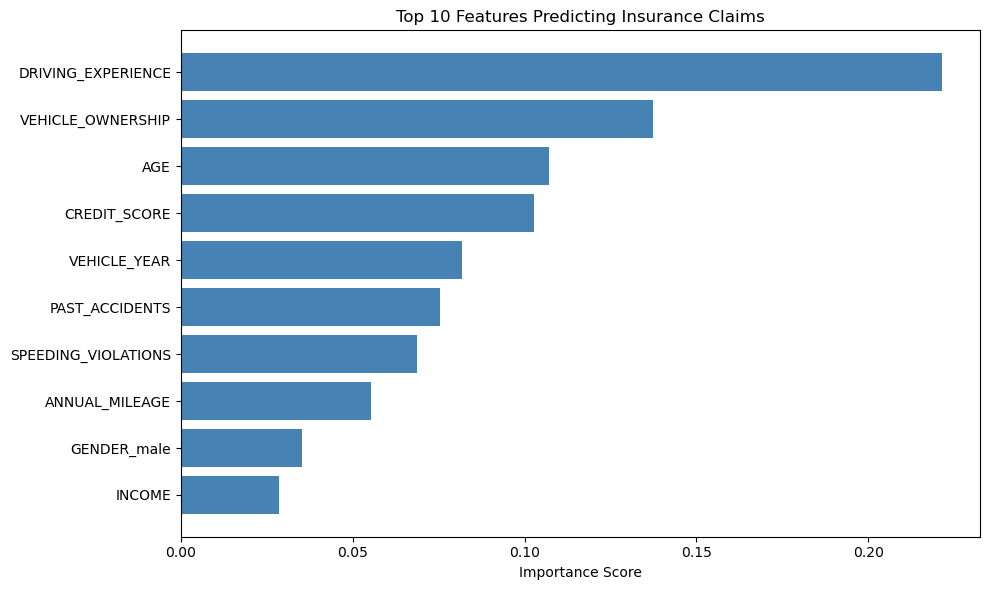

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 Features:")
print(importance_df.head(10))

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'].head(10), 
         importance_df['Importance'].head(10), 
         color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Features Predicting Insurance Claims')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [69]:
import os

df_export = X_test.copy()
df_export['OUTCOME'] = y_test.values
df_export['RISK_SCORE'] = rf.predict_proba(X_test)[:, 1]
df_export['RISK_CATEGORY'] = pd.cut(
    df_export['RISK_SCORE'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# Save in same folder as your notebook
df_export.to_csv('insurance_risk_scored.csv', index=False)

print("CSV saved successfully!")
print(f"Saved in: {os.getcwd()}")
print(f"\nRows: {len(df_export)}")
print("\nRisk breakdown:")
print(df_export['RISK_CATEGORY'].value_counts())

CSV saved successfully!
Saved in: C:\Users\dell

Rows: 2000

Risk breakdown:
RISK_CATEGORY
Low Risk       1214
High Risk       432
Medium Risk     354
Name: count, dtype: int64
